<a href="https://colab.research.google.com/github/bazhenamatnenko-spec/freshlink_AI/blob/main/Freshlink_AI.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
!pip install anthropic
import anthropic
from google.colab import userdata
import time
import json

anthropic_api_key = userdata.get('ANTHROPIC_API_KEY')
client = anthropic.Anthropic(api_key=anthropic_api_key)

print("Anthropic client initialized successfully.")

Anthropic client initialized successfully.


## Categorizing Food from Details

The overall goal of this section is to take input from the food provider (how they desribe their food) and structure it into a more organized format.

Part 1: Example Unstructured Input

In [ ]:
# We simulate a real input from a business user.
# This message is written in natural language and contains useful information (type of food, quantity, timing).
# However, it is unstructured and inconsistent—making it difficult for a system to process directly.
business_message = (
    "We are a bakery in downtown San Jose with about 40 leftover bagels "
    "and pastries. They are packaged and need to be picked up before 7pm today."
)


Part 2: Schema prompt

In [ ]:
# We define a strict schema using a system prompt.
# This schema has the AI extract specific fields (such as food category, quantity, urgency, and pickup details)
# It return them in a consistent JSON format.
# This step is critical because it transforms unpredictable text into reliable, machine-readable data.
schema_prompt = """
Extract information from this food waste marketplace message.

Return ONLY valid JSON with exactly these fields:
{
  "listing_type": "OFFER" or "REQUEST",
  "actor_type": "BUSINESS" or "INDIVIDUAL" or "NONPROFIT",
  "food_category": "PRODUCE" or "BAKERY" or "PREPARED_FOOD" or "PACKAGED" or "DAIRY" or "MEAT" or "MIXED" or "COMPOST_ONLY",
  "quantity_amount": number or null,
  "quantity_unit": "LBS" or "SERVINGS" or "BOXES" or "TRAYS" or "BAGS" or "UNKNOWN",
  "pickup_location": string or null,
  "pickup_deadline": string or null,
  "storage_requirement": "ROOM_TEMP" or "REFRIGERATED" or "FROZEN" or "UNKNOWN",
  "packaging_status": "SEALED" or "PACKAGED" or "OPEN_TRAY" or "UNPACKAGED" or "UNKNOWN",
  "safety_status": "SAFE_FOR_PEOPLE" or "ANIMAL_FEED" or "COMPOST_ONLY" or "UNKNOWN",
  "urgency": "LOW" or "MEDIUM" or "HIGH"
}

Urgency guide:
LOW = pickup can happen in more than 24 hours.
MEDIUM = pickup should happen today or tomorrow.
HIGH = food must be picked up within a few hours.

No explanation. No markdown. JSON only.
"""

Part 3: Extraction function

In [ ]:
# Takes a raw text message from a donor and converts it to structured JSON data
# using Claude with a predefined schema. Returns a dictionary the backend can use.

import base64
import io
# client is globally available from a previous cell
# Image is globally available from a previous cell

def extract_structured_food_listing(message):
    # Send the unstructured message to the AI using Anthropic's API
    # The system prompt contains our schema rules
    response = client.messages.create(
        model="claude-opus-4-6", # Changed from 'claude-3-haiku-20240307' to a working model
        max_tokens=1024,
        system=schema_prompt,
        messages=[
            {"role": "user", "content": message}
        ]
    )

    # Get raw text output from the model
    raw = response.content[0].text.strip()

    # Sometimes models wrap JSON in ```json ... ```
    # This removes markdown formatting if present
    if raw.startswith("```"):
        raw = raw.split("\n", 1)[1].rsplit("```", 1)[0].strip()

    # Convert JSON string → Python dictionary
    # This is what your backend will actually use
    return json.loads(raw)

Part 4: Run example

In [ ]:
# We run the system on a sample message to see how the AI interprets and organizes the information according to the schema.

# Run the extraction on the sample message
result = extract_structured_food_listing(business_message)

# Pretty-print the structured output
print(json.dumps(result, indent=2, ensure_ascii=False))

{
  "listing_type": "OFFER",
  "actor_type": "BUSINESS",
  "food_category": "BAKERY",
  "quantity_amount": 40,
  "quantity_unit": "UNKNOWN",
  "pickup_location": "downtown San Jose",
  "pickup_deadline": "7pm today",
  "storage_requirement": "ROOM_TEMP",
  "packaging_status": "PACKAGED",
  "safety_status": "SAFE_FOR_PEOPLE",
  "urgency": "HIGH"
}


Part 5: Batch testing (VERY important)

In [ ]:
# We test the system with multiple example messages representing different real-world scenarios (restaurants, grocery stores, individuals).
# This helps evaluate how robust and consistent the schema and extraction process are across varied inputs.

# These simulate different types of users and food scenarios
# Helps see if your schema is robust or breaks easily
test_messages = [
    {
        "label": "Restaurant leftovers",
        "message": "Our restaurant has 6 trays of cooked rice and vegetables left over. They are still warm and need pickup in the next hour."
    },
    {
        "label": "Grocery produce",
        "message": "We have three boxes of bruised bananas and apples. Still edible, but we cannot sell them."
    },
    {
        "label": "Resident compost",
        "message": "I have a bag of vegetable scraps from home. Not for eating, but good for compost."
    }
]

# Loop through each test case
for item in test_messages:
    print(f"=== {item['label']} ===")

    # Extract structured data for each message
    result = extract_structured_food_listing(item["message"])

    # Print results so you can debug / evaluate accuracy
    print(json.dumps(result, indent=2, ensure_ascii=False))

=== Restaurant leftovers ===
{
  "listing_type": "OFFER",
  "actor_type": "BUSINESS",
  "food_category": "PREPARED_FOOD",
  "quantity_amount": 6,
  "quantity_unit": "TRAYS",
  "pickup_location": null,
  "pickup_deadline": null,
  "storage_requirement": "ROOM_TEMP",
  "packaging_status": "OPEN_TRAY",
  "safety_status": "SAFE_FOR_PEOPLE",
  "urgency": "HIGH"
}
=== Grocery produce ===
{
  "listing_type": "OFFER",
  "actor_type": "BUSINESS",
  "food_category": "PRODUCE",
  "quantity_amount": 3,
  "quantity_unit": "BOXES",
  "pickup_location": null,
  "pickup_deadline": null,
  "storage_requirement": "ROOM_TEMP",
  "packaging_status": "UNPACKAGED",
  "safety_status": "SAFE_FOR_PEOPLE",
  "urgency": "MEDIUM"
}
=== Resident compost ===
{
  "listing_type": "OFFER",
  "actor_type": "INDIVIDUAL",
  "food_category": "COMPOST_ONLY",
  "quantity_amount": 1,
  "quantity_unit": "BAGS",
  "pickup_location": null,
  "pickup_deadline": null,
  "storage_requirement": "ROOM_TEMP",
  "packaging_status": "U

### Food Verfication: Image Upload

In this section, the primary goal is to make classify the food into safe for consumption vs unsafe. It does this by analyzing a photo of the food. If the AI determines it is safe, it it then listed for pickup.

Part 1: Upload Food Image

Please upload an image file:


Saving Screenshot 2026-05-09 at 4.10.46 PM.png to Screenshot 2026-05-09 at 4.10.46 PM (1).png
Uploaded: Screenshot 2026-05-09 at 4.10.46 PM (1).png
Image size: 658x494 pixels


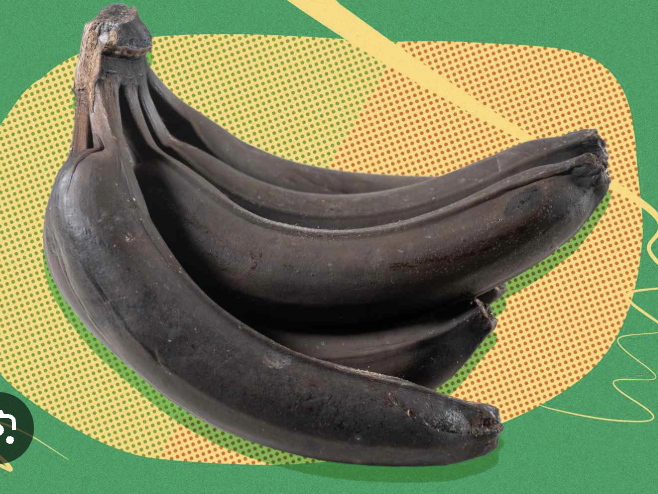

In [ ]:
# Upload an image of the food.
# This could be leftover restaurant food, grocery produce, or packaged food.
from PIL import Image
from google.colab import files

# Upload an image file
print("Please upload an image file:")
uploaded = files.upload()

# Get the filename of the uploaded image
image_filename = list(uploaded.keys())[0]

# Open and display the uploaded image
img = Image.open(image_filename)

print(f"Uploaded: {image_filename}")
print(f"Image size: {img.size[0]}x{img.size[1]} pixels")

display(img)

Part 2: Core Food Image Analysis Function

In [ ]:
# Sends a food image and a question to Anthropic.

# A function lets the AI analyze visual details in the image,
# Such as food type, quantity, packaging, and whether the food
# Appears suitable for donation, pickup, or compost.

# Returns:
# - response_text: the AI's written answer


import base64
import io
# client is globally available from a previous cell
# Image is globally available from a previous cell

def analyze_food_image(image_path, question):

    # Open the uploaded image.
    img = Image.open(image_path)

    # Convert PIL Image to Base64
    buffered = io.BytesIO()
    image_format = img.format if img.format else "PNG" # Default to PNG if format is unknown
    img.save(buffered, format=image_format)
    img_base64 = base64.b64encode(buffered.getvalue()).decode("utf-8")
    media_type = f"image/{image_format.lower()}"

    # Construct the messages for Anthropic API
    # Anthropic's vision models are generally claude-3 models
    model_name = "claude-opus-4-6" # Using Haiku for image analysis

    response = client.messages.create(
        model=model_name,
        max_tokens=1024, # A reasonable max_tokens for vision output
        messages=[
            {
                "role": "user",
                "content": [
                    {
                        "type": "image",
                        "source": {
                            "type": "base64",
                            "media_type": media_type,
                            "data": img_base64,
                        },
                    },
                    {
                        "type": "text",
                        "text": question,
                    },
                ],
            }
        ]
    )

    # Get raw text output from the model
    response_text = response.content[0].text.strip()

    # Anthropic's API returns usage in response.usage
    usage_metadata = {
        "input_tokens": response.usage.input_tokens,
        "output_tokens": response.usage.output_tokens,
        "total_token_count": response.usage.input_tokens + response.usage.output_tokens
    }

    # Return the model response and token usage.
    return response_text, usage_metadata

Part 3: Standard Food Marketplace Image Questions

In [ ]:
# We ask the AI a set of focused questions about the food image, such as identifying the food type, its condition, and what should be done with it.
# The code loops through each question, sends it along with the image to the AI, and stores the responses.

food_questions = [
    (
        "FOOD_TYPE",
        "Identify the type of food visible in this image."
    ),
    (
        "CONDITION",
        "Describe the visible condition of the food. Does it appear fresh, packaged, opened, damaged, spoiled, or compost-only? Explain briefly."
    ),
    (
        "MARKETPLACE_ACTION",
        "Based only on what is visible, should this food be listed for human pickup, nonprofit pickup, animal feed, compost, or marked as unknown? Explain your choice."
    )
]

food_results = {
    "answers": {},
    "total_tokens": 0
}

for label, question in food_questions:
    print(f"--- {label} ---")

    # Analyze the uploaded food image using the current question.
    answer, usage = analyze_food_image(image_filename, question)

    # Save the answer under its label.
    food_results["answers"][label] = answer

    # Add token usage to the total.
    food_results["total_tokens"] += usage['total_token_count']

    print(answer)
    print()

print(f"--- Total tokens used: {food_results['total_tokens']} ---")

--- FOOD_TYPE ---
# Overripe Bananas

The image shows a bunch of **bananas** that have become extremely **overripe**, as evidenced by their **completely blackened skin**. While they may look unappetizing, bananas at this stage are actually:

- **Very sweet** due to the starches having fully converted to sugars
- **Ideal for baking** — perfect for banana bread, muffins, or smoothies
- **Still safe to eat** (as long as the flesh inside isn't moldy)

The image appears to be a styled/editorial photo with a colorful green and yellow graphic background.

--- CONDITION ---
# Food Condition Assessment

**Condition: Spoiled / Compost-only**

The bananas are **extremely overripe to the point of being spoiled**. Their skin has turned completely **black/dark brown**, indicating significant decomposition well beyond normal ripeness. At this stage:

- The flesh inside is likely **mushy, fermented, and liquefied**
- They are **past the point of being edible** even for baking (banana bread typically c

Part 4: Structured Listing From Image

In [ ]:
# We ask the AI to analyze the food image and return all details.
# The prompt defines exactly what fields the AI must include, ensuring the output is consistent and usable for the app.
# The result is a structured food listing that can be directly stored or processed
structured_food_prompt = """
Analyze this food image for a food waste marketplace app.

Return ONLY valid JSON with exactly these fields:
{
  "listing_type": "OFFER" or "REQUEST" or "UNKNOWN",
  "food_category": "PRODUCE" or "BAKERY" or "PREPARED_FOOD" or "PACKAGED" or "DAIRY" or "MEAT" or "MIXED" or "COMPOST_ONLY" or "UNKNOWN",
  "estimated_quantity": string or null,
  "packaging_status": "SEALED" or "PACKAGED" or "OPEN_TRAY" or "UNPACKAGED" or "UNKNOWN",
  "visible_condition": "FRESH" or "NEAR_EXPIRY" or "DAMAGED" or "SPOILED" or "UNKNOWN",
  "storage_requirement": "ROOM_TEMP" or "REFRIGERATED" or "FROZEN" or "UNKNOWN",
  "safety_status": "LIKELY_SAFE_FOR_PEOPLE" or "COMPOST_ONLY" or "UNKNOWN",
  "recommended_action": "LIST_FOR_PICKUP" or "SEND_TO_NONPROFIT" or "COMPOST" or "NEEDS_HUMAN_REVIEW",
  "notes": string
}

Important:
Only use what is visible in the image.
Do not guess hidden details like expiration date, ingredients, or exact weight.
No markdown. No explanation outside the JSON.
"""

structured_result, structured_usage = analyze_food_image(
    image_filename,
    structured_food_prompt
)

print("--- Structured Food Listing ---")
print(structured_result)

--- Structured Food Listing ---
```json
{
  "listing_type": "OFFER",
  "food_category": "PRODUCE",
  "estimated_quantity": "1 bunch (approximately 4-5 bananas)",
  "packaging_status": "UNPACKAGED",
  "visible_condition": "SPOILED",
  "storage_requirement": "ROOM_TEMP",
  "safety_status": "COMPOST_ONLY",
  "recommended_action": "COMPOST",
  "notes": "Bananas are entirely black/dark brown, indicating extreme overripeness or spoilage. While heavily overripe bananas can sometimes still be used for baking (banana bread), these appear to be beyond typical culinary use. The skin is uniformly blackened with no yellow remaining. If the interior flesh is still intact and not fermented, they could potentially be used for baking, but a human review or compost is recommended given their external appearance."
}
```


Part 5: High-risk foods go to human review

In [ ]:
# This function checks whether a listing should be reviewed by a human before it becomes public on the marketplace.
def needs_human_review(listing):
    high_risk_categories = ["MEAT", "DAIRY", "PREPARED_FOOD"]
    risky_statuses = ["UNKNOWN", "COMPOST_ONLY"]

    # Check for known high-risk food categories
    if listing["food_category"] in high_risk_categories:
        return True

    # Check for risky safety statuses determined by AI
    if listing["safety_status"] in risky_statuses:
        return True

    # Check for packaging that might indicate higher risk or handling concerns
    if listing["packaging_status"] in ["OPEN_TRAY", "UNPACKAGED"]:
        return True

if needs_human_review(result):
    print("This listing needs human review before being published.")
else:
    print("This listing can move forward automatically.")

This listing needs human review before being published.


Part 6: Approved listings become public

In [ ]:
# This function simulates publishing a listing to the marketplace
# Only listings that are approved or low-risk should become public.
public_listings = []

def publish_listing(listing):
    listing["status"] = "PUBLIC"
    public_listings.append(listing)
    return listing

# Example:

if not needs_human_review(result):
    published_listing = publish_listing(result)
    print("Listing published:")
    print(json.dumps(published_listing, indent=2))
else:
    result["status"] = "PENDING_REVIEW"
    print("Listing is waiting for human review.")

Listing is waiting for human review.


Part **7**: Users select and reserve pickup

In [ ]:
# Define a simplified function for reserving a food listing.
# This function attempts to change a listing's status to 'RESERVED'.
def reserve_pickup_simplified(listing, user_name):
    # First, check if the listing's current status is 'PUBLIC'.
    # Only public listings can be reserved to prevent reserving unapproved items.
    if listing.get("status") != "PUBLIC":
        print(f"Warning: Listing is not PUBLIC. Current status: {listing.get('status')}. Cannot reserve.")
        return None # If not public, return None or raise an error.

    # If the listing is public, update its status to 'RESERVED'.
    listing["status"] = "RESERVED"
    # Record the name of the user who reserved the listing.
    listing["reserved_by"] = user_name
    return listing # Return the updated listing.

# --- Example Usage ---

# Create a sample listing that is 'PUBLIC' to demonstrate a successful reservation.
simple_listing = {
    "listing_type": "OFFER",
    "food_category": "PRODUCE",
    "status": "PUBLIC",
    "notes": "Fresh apples"
}

print("Original Simple Listing:")
print(json.dumps(simple_listing, indent=2))

# Attempt to reserve the simple_listing.
simplified_reserved_listing = reserve_pickup_simplified(simple_listing, "Bob")

# If the reservation was successful (i.e., not None), print the reserved listing.
if simplified_reserved_listing:
    print("\nSimplified Reserved Listing:")
    print(json.dumps(simplified_reserved_listing, indent=2))

# Create another sample listing that is 'PENDING_REVIEW' to demonstrate a failed reservation.
# This listing should not be reservable.
non_public_listing = {
    "listing_type": "OFFER",
    "food_category": "DAIRY",
    "status": "PENDING_REVIEW",
    "notes": "Milk for review"
}

print("\nOriginal Non-Public Listing:")
print(json.dumps(non_public_listing, indent=2))

# Attempt to reserve the non_public_listing.
reserved_non_public = reserve_pickup_simplified(non_public_listing, "Alice")
# This should print a warning and return None, so this block won't execute.
if reserved_non_public:
    print("\nReserved Non-Public Listing:")
    print(json.dumps(reserved_non_public, indent=2))


Original Simple Listing:
{
  "listing_type": "OFFER",
  "food_category": "PRODUCE",
  "status": "PUBLIC",
  "notes": "Fresh apples"
}

Simplified Reserved Listing:
{
  "listing_type": "OFFER",
  "food_category": "PRODUCE",
  "status": "RESERVED",
  "notes": "Fresh apples",
  "reserved_by": "Bob"
}

Original Non-Public Listing:
{
  "listing_type": "OFFER",
  "food_category": "DAIRY",
  "status": "PENDING_REVIEW",
  "notes": "Milk for review"
}


## Failure Case:

In [ ]:
import json
# === FAILURE CASE TEST:
#AI is unable to predict possible problems with food that appears low risk, but has a possibility to cause horrible illness.
#For Example:
# Home-canned green beans (botulism risk) ===

# Why this is unsafe:
# Home-canned low-acid vegetables (green beans, corn) require pressure
# canning to destroy Clostridium botulinum spores.
# The CDC explicitly warns against accepting home-canned low-acid foods from unknown sources.
# To prevent this, feed the AI more context and apply filters, so that it can return "red flags"

unsafe_message = (
    "Cleaning out our restaurant pantry. Got 30 sealed jars of "
    "home-canned green beans from last summer's garden harvest. "
    "All sealed and shelf-stable, free for pickup whenever."
)

print("STEP 1 — Input message")
print("-" * 60)
print(unsafe_message)
print()

# Run the same extraction the real system would run.
unsafe_result = extract_structured_food_listing(unsafe_message)

print("STEP 2 — AI extraction (claude-opus-4-6)")
print("-" * 60)
print(json.dumps(unsafe_result, indent=2))
print()

# Apply the human-review gate.
review_needed = needs_human_review(unsafe_result)

print("STEP 3 — needs_human_review() decision")
print("-" * 60)
print(f"food_category    = {unsafe_result['food_category']}")
print(f"safety_status    = {unsafe_result['safety_status']}")
print(f"packaging_status = {unsafe_result['packaging_status']}")
print(f"needs_human_review -> {review_needed}")
print()

# What the marketplace would actually do with this listing.
print("STEP 4 — Marketplace action")
print("-" * 60)
if review_needed:
    unsafe_result["status"] = "PENDING_REVIEW"
    print("Routed to human review. (Pipeline caught it.)")
else:
    published = publish_listing(unsafe_result)
    print("Published to public marketplace:")
    print(json.dumps(published, indent=2))
    print()

    # And confirm a regular user could now reserve it.
    print("STEP 5 — Can a user reserve this listing?")
    print("-" * 60)
    reserved = reserve_pickup_simplified(published, "Test User")
    if reserved:
        print(json.dumps(reserved, indent=2))

print()
print("=" * 60)
print("VERDICT")
print("=" * 60)
if not review_needed and unsafe_result["safety_status"] == "SAFE_FOR_PEOPLE":
    print("FAILURE: The AI classified an unsafe food as SAFE_FOR_PEOPLE,")
    print("the human-review gate let it through, and the listing was")
    print("published and made reservable. A real user could have picked")
    print("up potentially botulism-contaminated jars.")
else:
    print("PASS on this run. Re-run a few times — the model is non-")
    print("deterministic and often flips on borderline cases.")

STEP 1 — Input message
------------------------------------------------------------
Cleaning out our restaurant pantry. Got 30 sealed jars of home-canned green beans from last summer's garden harvest. All sealed and shelf-stable, free for pickup whenever.

STEP 2 — AI extraction (claude-opus-4-6)
------------------------------------------------------------
{
  "listing_type": "OFFER",
  "actor_type": "BUSINESS",
  "food_category": "PRODUCE",
  "quantity_amount": 30,
  "quantity_unit": "UNKNOWN",
  "pickup_location": null,
  "pickup_deadline": null,
  "storage_requirement": "ROOM_TEMP",
  "packaging_status": "SEALED",
  "safety_status": "SAFE_FOR_PEOPLE",
  "urgency": "LOW"
}

STEP 3 — needs_human_review() decision
------------------------------------------------------------
food_category    = PRODUCE
safety_status    = SAFE_FOR_PEOPLE
packaging_status = SEALED
needs_human_review -> None

STEP 4 — Marketplace action
------------------------------------------------------------
Published 